In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('../data/twitter.csv', encoding="latin-1", header=None)

In [5]:
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   0       1600000 non-null  int64 
 1   1       1600000 non-null  int64 
 2   2       1600000 non-null  object
 3   3       1600000 non-null  object
 4   4       1600000 non-null  object
 5   5       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [7]:
df.columns = ["sentiment", "id", "date", "query", "user", "text"]

In [8]:
df["sentiment"] = df["sentiment"].replace({0:"Negative", 4:"Positive"})
df["sentiment"].value_counts()

sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64

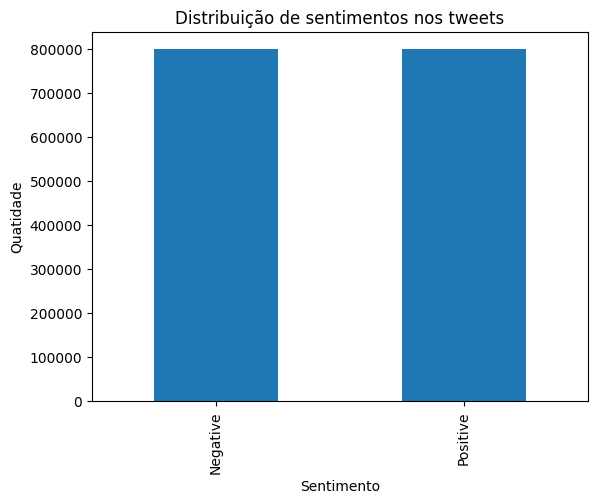

In [9]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar") #quantidade de sentimentos

plt.title("Distribuição de sentimentos nos tweets")
plt.xlabel("Sentimento")
plt.ylabel("Quatidade")
plt.show()

In [22]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
Negative    50.0
Positive    50.0
Name: proportion, dtype: float64

In [10]:
import sys
sys.path.append('../')
from src.limpeza import limpar_texto

df["texto_limpo"] = df["text"].apply(limpar_texto)

In [11]:
from collections import Counter

texto = " ".join(df["texto_limpo"])

palavras = texto.split()

mais_usadas = Counter(palavras)
mais_usadas.most_common(20)

[('i', 751301),
 ('to', 564591),
 ('the', 520094),
 ('a', 378001),
 ('my', 314119),
 ('and', 298466),
 ('you', 270155),
 ('is', 236031),
 ('it', 230924),
 ('for', 215724),
 ('in', 214386),
 ('of', 183447),
 ('im', 178401),
 ('on', 167122),
 ('me', 160210),
 ('so', 150834),
 ('have', 144550),
 ('that', 141356),
 ('but', 127522),
 ('just', 125070)]

In [ ]:
X = df["texto_limpo"]
y = df["sentiment"]


<class 'pandas.core.series.Series'>
0     httptwitpiccomyzl  awww thats a bummer  you s...
1    is upset that he cant update his facebook by t...
2     i dived many times for the ball managed to sa...
3      my whole body feels itchy and like its on fire 
4     no its not behaving at all im mad why am i he...
Name: texto_limpo, dtype: object


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.naive_bayes import MultinomialNB

modelo = MultinomialNB()

modelo.fit( X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [21]:
from sklearn.metrics import accuracy_score

predicao = modelo.predict(X_test)

accuracy_score(y_test, predicao)

0.769146875